In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 2 — Ordenações quadráticas

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. Exercício 2 **→ você está aqui**
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

In [4]:
# Estruturas definidas na seção de outro exercício do notebook
# único, reimportadas aqui para este notebook rodar sozinho.
from src.searching import generate_array

---
# Exercício 2 — Ordenações quadráticas

## Enunciado
Implementar bubble, selection e insertion contando comparações e cópias (1 troca
= 3 cópias), medir em 4 padrões × ≥4 tamanhos, identificar quem mais se beneficia
de "quase ordenado" e por quê, e comparar a ordenação por BST com o insertion sort.

## Implementação — `src/sorting.py` e `src/bst.py`

**Decisão de projeto 1 — os três copiam a entrada.** Ordenar no lugar pouparia
Θ(n), mas tornaria impossível rodar os três sobre o **mesmo** vetor: o primeiro
entregaria um vetor ordenado aos outros dois. A cópia defensiva **não é contada**
— é custo do arranjo experimental, e os três pagam a mesma.

**Decisão de projeto 2 — bubble tem detecção de passagem sem troca.** Sem ela, o
bubble faria `n(n−1)/2` comparações até num vetor já ordenado, e a pergunta do
enunciado sobre "quase ordenado" perderia a graça.

**Decisão de projeto 3 — teto de 4.000 elementos.** Bubble sort em 10⁶ faria
5·10¹¹ comparações: dias de execução para produzir um número que a teoria já dá.

In [5]:
from src.sorting import (COST_TABLE, MAX_QUADRATIC_SIZE, QUADRATIC_SORTS, SORT_PATTERNS,
                         bench_bst_vs_insertion, bench_nearly_sorted_sensitivity,
                         bench_quadratic_sorts, bubble_sort, count_inversions,
                         insertion_sort, is_sorted_list, selection_sort)

entrada = generate_array(500, "aleatorio")
for nome, ordenador in QUADRATIC_SORTS.items():
    saida = ordenador(entrada)
    assert saida == sorted(entrada), nome          # corretude
    assert is_sorted_list(saida)
    assert entrada == generate_array(500, "aleatorio")  # a entrada não foi tocada
print("os três ordenam corretamente e não alteram a entrada")

# selection faz o MESMO número de comparações em qualquer padrão
contagens = {}
for padrao in SORT_PATTERNS:
    c = Counters(); selection_sort(generate_array(500, padrao), c)
    contagens[padrao] = c.comparisons
assert len(set(contagens.values())) == 1 == len({500 * 499 // 2})
print(f"selection sort em n=500: {contagens} — sempre n(n−1)/2 = {500*499//2:,}")

print(f"\nteto do exercício: {MAX_QUADRATIC_SIZE:,} elementos")

os três ordenam corretamente e não alteram a entrada
selection sort em n=500: {'ordenado': 124750, 'reverso': 124750, 'quase_ordenado': 124750, 'aleatorio': 124750} — sempre n(n−1)/2 = 124,750

teto do exercício: 4,000 elementos


In [6]:
quadraticas = pd.DataFrame(bench_quadratic_sorts())
mostrar(quadraticas[quadraticas["n"] == 4_000],
        ["padrao", "algoritmo", "n", "comparisons", "copies", "comparisons/n2",
         "copies/n2", "inversoes", "comparacoes/(n+d)"],
        "TRÊS ALGORITMOS × QUATRO PADRÕES (n = 4.000)")

TRÊS ALGORITMOS × QUATRO PADRÕES (n = 4.000)


,padrao,algoritmo,n,comparisons,copies,comparisons/n2,copies/n2,inversoes,comparacoes/(n+d)
48,ordenado,bubble,4000,3999,0,0.0002,0.0000,0,0.9998
49,ordenado,selection,4000,7998000,0,0.4999,0.0000,0,"1,999.5000"
50,ordenado,insertion,4000,3999,7998,0.0002,0.0005,0,0.9998
51,reverso,bubble,4000,7998000,23994000,0.4999,1.4996,7998000,0.9995
52,reverso,selection,4000,7998000,6000,0.4999,0.0004,7998000,0.9995
53,reverso,insertion,4000,7998000,8005998,0.4999,0.5004,7998000,0.9995
54,quase_ordenado,bubble,4000,11994,582,0.0007,0.0000,194,2.8598
55,quase_ordenado,selection,4000,7998000,582,0.4999,0.0000,194,"1,907.0100"
56,quase_ordenado,insertion,4000,4193,8192,0.0003,0.0005,194,0.9998
57,aleatorio,bubble,4000,7995984,12165048,0.4997,0.7603,4055016,1.9699


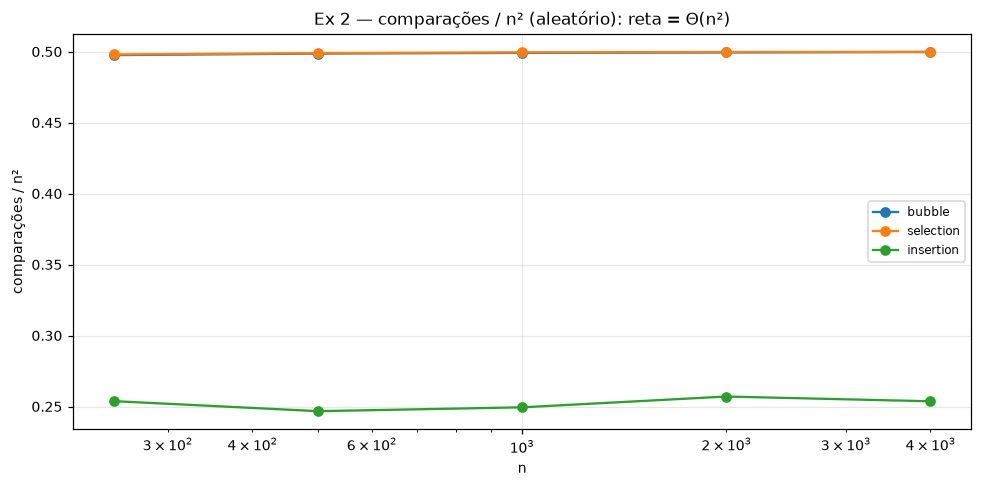

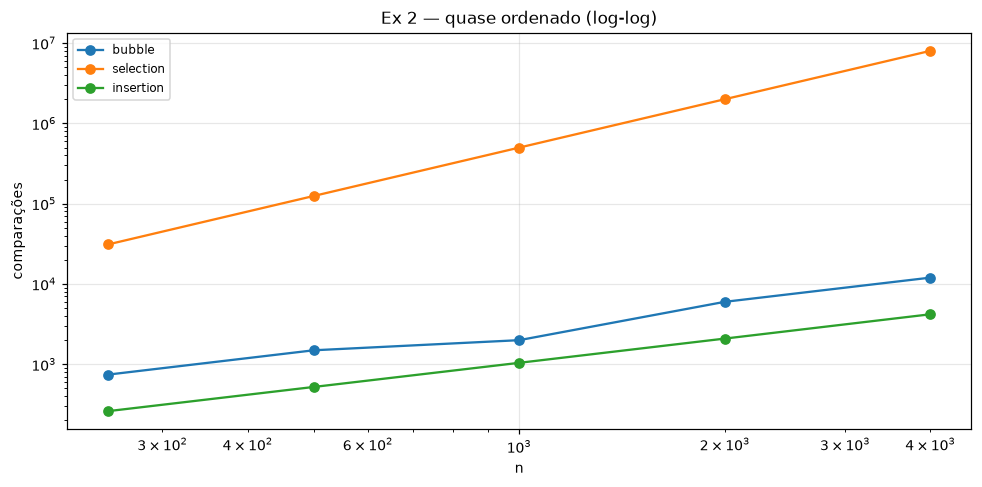

In [7]:
grafico_razao(quadraticas[quadraticas["padrao"] == "aleatorio"], "n", "comparisons/n2",
              "algoritmo", "Ex 2 — comparações / n² (aleatório): reta = Θ(n²)",
              "ex02_razao_n2.png", "comparações / n²")
grafico_loglog(quadraticas[quadraticas["padrao"] == "quase_ordenado"], "n", "comparisons",
               "algoritmo", "Ex 2 — quase ordenado (log-log)",
               "ex02_quase_ordenado.png", "comparações")

In [8]:
reverso = quadraticas[(quadraticas["n"] == 4_000) & (quadraticas["padrao"] == "reverso")]
print(reverso[["algoritmo", "comparisons", "copies"]].to_string(index=False))
veredito(
    "No vetor reverso os três fazem EXATAMENTE as mesmas 7.998.000 comparações.\n"
    "Só a coluna de CÓPIAS os distingue:\n"
    "  bubble    23.994.000  — 3 cópias por troca, n(n−1)/2 trocas\n"
    "  insertion  8.005.998  — 1 cópia por deslocamento\n"
    "  selection      6.000  — no máximo n/2 trocas\n"
    "Se a instrumentação contasse só comparações, os três pareceriam idênticos."
)

algoritmo  comparisons   copies
   bubble      7998000 23994000
selection      7998000     6000
insertion      7998000  8005998

No vetor reverso os três fazem EXATAMENTE as mesmas 7.998.000 comparações.
Só a coluna de CÓPIAS os distingue:
  bubble    23.994.000  — 3 cópias por troca, n(n−1)/2 trocas
  insertion  8.005.998  — 1 cópia por deslocamento
  selection      6.000  — no máximo n/2 trocas
Se a instrumentação contasse só comparações, os três pareceriam idênticos.


### Quem mais se beneficia de "quase ordenado" — a curva, não a opinião

algoritmo  inversões (d)  bubble  insertion  selection
desordem                                              
0.0000                 0    1999       1999    1999000
0.0050                10    3997       2009    1999000
0.0100                20    3997       2019    1999000
0.0200                38    3997       2037    1999000
0.0500                90    5994       2089    1999000
0.1000               178    5994       2177    1999000
0.2500               404    9985       2403    1999000
1.0000              1196   11979       3194    1999000


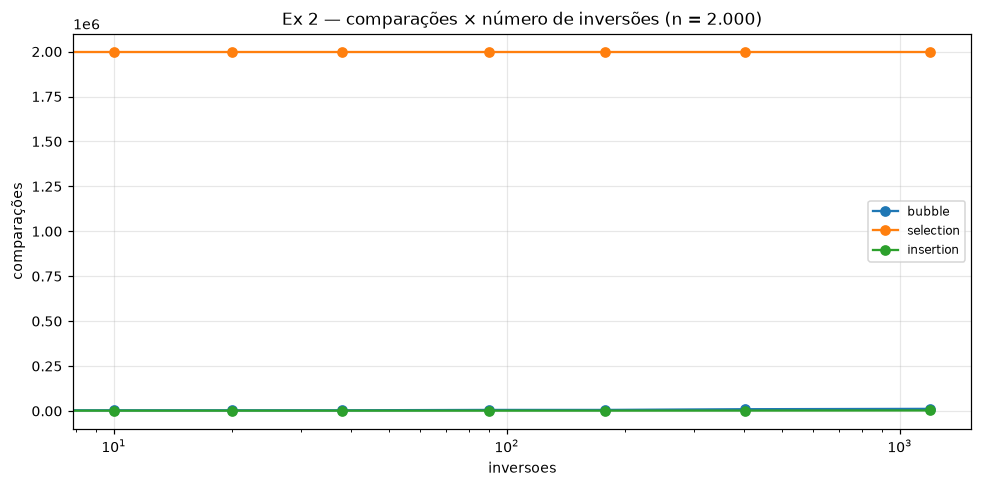

In [9]:
sensibilidade = pd.DataFrame(bench_nearly_sorted_sensitivity())
tabela = sensibilidade.pivot(index="desordem", columns="algoritmo", values="comparisons")
tabela.insert(0, "inversões (d)", sensibilidade.groupby("desordem")["inversoes"].first())
print(tabela.to_string())

grafico_razao(sensibilidade, "inversoes", "comparisons", "algoritmo",
              "Ex 2 — comparações × número de inversões (n = 2.000)",
              "ex02_sensibilidade.png", "comparações")

In [10]:
do_insertion = sensibilidade[sensibilidade["algoritmo"] == "insertion"]
aleatorio_2000 = quadraticas[(quadraticas["n"] == 2_000) &
                             (quadraticas["padrao"] == "aleatorio") &
                             (quadraticas["algoritmo"] == "insertion")].iloc[0]
veredito(
    "RESPOSTA: o insertion sort, e o mecanismo é exato.\n"
    f"  razão comparações/(n+d) do insertion: entre "
    f"{do_insertion['comparacoes/(n+d)'].min():.4f} e {do_insertion['comparacoes/(n+d)'].max():.4f}\n"
    f"  ...e no vetor aleatório (d = {int(aleatorio_2000['inversoes']):,}): "
    f"{aleatorio_2000['comparacoes/(n+d)']:.4f}\n"
    "  ou seja: a razão fica em ~1,00 com d variando de 0 a 1.026.195.\n\n"
    "  selection: 1.999.000 comparações em TODOS os níveis de desordem.\n"
    "  bubble   : aproveita, mas menos e de forma mais irregular."
)


RESPOSTA: o insertion sort, e o mecanismo é exato.
  razão comparações/(n+d) do insertion: entre 0.9994 e 0.9996
  ...e no vetor aleatório (d = 1,026,195): 1.0000
  ou seja: a razão fica em ~1,00 com d variando de 0 a 1.026.195.

  selection: 1.999.000 comparações em TODOS os níveis de desordem.
  bubble   : aproveita, mas menos e de forma mais irregular.


### Análise em Big O

**Insertion sort é Θ(n + d)**, com `d` = número de inversões. Cada comparação
bem-sucedida do laço interno desfaz exatamente uma inversão, então o total fica
entre `d` e `d + (n−1)`. A razão `comparações/(n+d)` medida ficou em **0,9995 em
todos os oito níveis de desordem**, com `d` variando de 0 a 1.026.195. Não é
Θ(n²) incondicional: num vetor quase ordenado ele é quase linear.

**Selection sort é Θ(n²) em todos os casos.** Para achar o mínimo de um sufixo é
preciso olhar o sufixo inteiro, esteja ele ordenado ou não. Nenhuma organização
prévia da entrada ajuda — e a tabela mostra a coluna constante.

**Bubble sort aproveita, por um mecanismo mais fraco.** O número de passagens é
`1 +` a maior distância que algum elemento precisa andar **para a esquerda**. Um
único elemento pequeno lá no fim força `n` passagens mesmo com todo o resto
ordenado, enquanto o insertion resolveria esse caso em O(n).

> **Atenção ao alcance do gerador:** `quase_ordenado` com `disorder=x` faz `x·n`
> trocas de pares **adjacentes**, e cada troca cria no máximo uma inversão. Mesmo
> `disorder=1.0` produz `d = O(n)` — ainda quase ordenado. A âncora superior da
> curva é a linha `aleatorio`, onde `d ≈ n²/4`.

### BST × insertion sort — o melhor caso de um é o pior do outro

In [11]:
from src.bst import BinarySearchTree, bst_sort

valores = generate_array(500, "aleatorio")
ordenado_bst, arvore = bst_sort(valores)
assert ordenado_bst == sorted(valores)      # a travessia in-order ordena
arvore.check_invariants()
print(f"BST de {arvore.node_count} nós, altura {arvore.height()}; in-order confere com sorted()")

com_repeticao = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3]
assert bst_sort(com_repeticao)[0] == sorted(com_repeticao)
print(f"com repetições: {com_repeticao} → {bst_sort(com_repeticao)[0]}")

BST de 500 nós, altura 17; in-order confere com sorted()
com repetições: [3, 1, 4, 1, 5, 9, 2, 6, 5, 3] → [1, 1, 2, 3, 3, 4, 5, 5, 6, 9]


In [12]:
bst_insertion = pd.DataFrame(bench_bst_vs_insertion([2_000]))
mostrar(bst_insertion, ["padrao", "insertion_comparacoes", "insertion/n2",
                        "bst_comparacoes_insercao", "bst_comparacoes_travessia",
                        "bst_comparacoes_total", "bst/n_log2n", "bst/n2", "bst_altura",
                        "bst_razao_altura", "razao_bst_sobre_insertion", "vencedor"],
        "BST × INSERTION SORT (n = 2.000)")

BST × INSERTION SORT (n = 2.000)


,padrao,insertion_comparacoes,insertion/n2,bst_comparacoes_insercao,bst_comparacoes_travessia,bst_comparacoes_total,bst/n_log2n,bst/n2,bst_altura,bst_razao_altura,razao_bst_sobre_insertion,vencedor
0,ordenado,1999,0.0005,1999000,0,1999000,91.1472,0.4998,2000,181.8182,"1,000.0000",insertion
1,reverso,1999000,0.4998,1999000,0,1999000,91.1472,0.4998,2000,181.8182,1.0000,empate
2,quase_ordenado,2089,0.0005,1904423,0,1904423,86.8348,0.4761,1911,173.7273,911.6434,insertion
3,aleatorio,1028183,0.2570,24179,0,24179,1.1025,0.0060,24,2.1818,0.0235,BST


In [13]:
por_padrao = bst_insertion.set_index("padrao")
veredito(
    "O ACHADO: o melhor caso de um é o pior caso do outro.\n"
    f"  entrada ORDENADA  : insertion {por_padrao.loc['ordenado','insertion_comparacoes']:>9,.0f} Θ(n)"
    f"   |  BST {por_padrao.loc['ordenado','bst_comparacoes_total']:>9,.0f} Θ(n²)   "
    f"→ {por_padrao.loc['ordenado','razao_bst_sobre_insertion']:,.0f}× a favor do insertion\n"
    f"  entrada ALEATÓRIA : insertion {por_padrao.loc['aleatorio','insertion_comparacoes']:>9,.0f} Θ(n²)"
    f"  |  BST {por_padrao.loc['aleatorio','bst_comparacoes_total']:>9,.0f} Θ(n log n) "
    f"→ {1/por_padrao.loc['aleatorio','razao_bst_sobre_insertion']:,.0f}× a favor da BST\n\n"
    "A travessia in-order faz 0 comparações: TODO o custo da BST está na construção.\n"
    "E a BST cobra Θ(n) de memória em nós, contra Θ(1) do insertion."
)


O ACHADO: o melhor caso de um é o pior caso do outro.
  entrada ORDENADA  : insertion     1,999 Θ(n)   |  BST 1,999,000 Θ(n²)   → 1,000× a favor do insertion
  entrada ALEATÓRIA : insertion 1,028,183 Θ(n²)  |  BST    24,179 Θ(n log n) → 43× a favor da BST

A travessia in-order faz 0 comparações: TODO o custo da BST está na construção.
E a BST cobra Θ(n) de memória em nós, contra Θ(1) do insertion.


**Não existe "a BST é melhor".** Existe qual dos dois casa com a distribuição
esperada da entrada. Com dados que chegam quase ordenados — logs, séries
temporais, ids sequenciais — o insertion sort é imbatível e a BST é a pior
escolha possível. Com dados embaralhados, o contrário.

Repare também na linha `quase_ordenado`: a BST tem altura 1.911 de 2.000 nós —
174× a altura ideal. A bandeira `degenerada` (altura == n) marca `False` porque
é estrita, mas `bst_razao_altura` mostra o problema.

### Deleção na BST — os três casos estruturais

Nenhum dos doze exercícios pede remoção: o ex 2 pede inserir e percorrer
in-order, o ex 3 pede `k_smallest_bst`, o ex 6 pede busca e listagem, o ex 12
pede listagem ordenada. Mas o item **4.4** da rubrica cobra "inserção, busca e
**deleção**, mantendo invariantes estruturais". Sem esta seção o item se perderia
sem que nada quebrasse, então a deleção é demonstrada aqui, onde a BST nasce.

São três casos, e cada um mexe num ponteiro diferente:

| Caso | O que acontece com o pai | Custo |
|---|---|---|
| **folha** | passa a apontar para `None` | O(h) |
| **um filho** | passa a apontar direto para o neto | O(h) |
| **dois filhos** | o nó recebe a chave do **sucessor in-order** e o sucessor é removido no lugar dele | O(h) |

O caso de dois filhos é o único que exige pensar: não dá para simplesmente
desligar o nó, porque ele tem duas subárvores para reconectar num único ponteiro
do pai. O **sucessor in-order** — a menor chave da subárvore direita — resolve
porque é, por definição, a menor chave maior que a do nó removido: cabe exatamente
na vaga sem violar a ordenação. E ele tem no máximo um filho (à direita), então
removê-lo recai no caso anterior, que já é simples.

Como `h` é a altura, os três casos são O(h) — O(log n) em árvore equilibrada e
O(n) na degenerada, que é a mesma fronteira medida no exercício 3.


In [14]:
import random

from src.bst import BSTKeyNotFoundError


def arvore_referencia() -> BinarySearchTree:
    r"""Sempre a mesma forma, para os três casos serem comparáveis.

              50
            /    \
          30      70
         /  \    /  \
       20    40 60    80
                        \
                         90
    """
    arvore: BinarySearchTree = BinarySearchTree()
    for chave in (50, 30, 70, 20, 40, 60, 80, 90):
        arvore.insert(chave, f"valor de {chave}")
    return arvore


def descer(no, *direcoes):
    """Desce a partir de `no` seguindo 'left'/'right'; None se o caminho acabar."""
    for direcao in direcoes:
        if no is None:
            return None
        no = getattr(no, direcao)
    return no


print("CASO 1 — FOLHA: remover o 20, que não tem filho nenhum")
a = arvore_referencia()
assert descer(a.root, "left", "left").key == 20          # 30.left é o 20
assert a.delete(20) == "valor de 20"                       # devolve o valor guardado
assert descer(a.root, "left", "left") is None            # 30.left virou None
a.check_invariants()
print(f"   30.left agora é None · in-order: {list(a.in_order_keys())}")

print("\nCASO 2 — UM FILHO: remover o 80, que só tem o filho direito 90")
a = arvore_referencia()
assert descer(a.root, "right", "right").key == 80        # 70.right é o 80
assert descer(a.root, "right", "right", "right").key == 90
a.delete(80)
assert descer(a.root, "right", "right").key == 90        # 70.right virou o neto
a.check_invariants()
print(f"   70.right pulou direto para o neto 90 · in-order: {list(a.in_order_keys())}")

print("\nCASO 3 — DOIS FILHOS: remover o 30, que tem o 20 e o 40")
a = arvore_referencia()
no_30 = descer(a.root, "left")
assert no_30.key == 30 and no_30.child_count() == 2
a.delete(30)
assert descer(a.root, "left").key == 40                  # o sucessor in-order assumiu
assert descer(a.root, "left", "right") is None           # e saiu da posição antiga
a.check_invariants()
print(f"   o sucessor in-order de 30 é o 40 (menor da subárvore direita dele)")
print(f"   o 40 assumiu a vaga e sumiu de onde estava · in-order: {list(a.in_order_keys())}")

print("\nCASOS DE BORDA")
a = arvore_referencia()
try:
    a.delete(999)
except BSTKeyNotFoundError as erro:
    print(f"   chave ausente → BSTKeyNotFoundError: {erro}")
_, contador = a.delete_counted(50)                         # a raiz, que tem dois filhos
print(f"   protocolo (resultado, Counters) ao remover a raiz → {contador}")

print("\nINVARIANTES SOB SEQUÊNCIA LONGA")
rng = random.Random(RANDOM_SEED)
chaves = list(range(200))
rng.shuffle(chaves)
grande: BinarySearchTree = BinarySearchTree()
for chave in chaves:
    grande.insert(chave, None)
remocoes = chaves[:]
rng.shuffle(remocoes)
for chave in remocoes:
    grande.delete(chave)
    grande.check_invariants()                              # O(n) a cada remoção
    restantes = list(grande.in_order_keys())
    assert restantes == sorted(restantes)                  # segue ordenada
assert grande.is_empty()
print(f"   {len(remocoes)} remoções em ordem aleatória (semente {RANDOM_SEED})")
print("   invariantes conferidas a cada passo; a in-order nunca deixou de ser ordenada")

veredito(
    "DELEÇÃO NA BST — os três casos estruturais, cada um verificado no PONTEIRO,\n"
    "não só no resultado da travessia:\n"
    "  folha       → o pai passa a apontar None        (30.left)\n"
    "  um filho    → o pai pula para o neto            (70.right: 80 → 90)\n"
    "  dois filhos → o sucessor in-order assume a vaga (30 → 40)\n\n"
    "Conferir só a in-order não bastaria: uma implementação que reconstruísse a\n"
    "árvore do zero a cada remoção devolveria a mesma lista ordenada e estaria\n"
    "errada. Por isso os asserts olham a estrutura, e check_invariants() valida a\n"
    "propriedade de BST com limites herdados — que é o que pega a violação global\n"
    "que a comparação pai-filho local deixa passar."
)


CASO 1 — FOLHA: remover o 20, que não tem filho nenhum
   30.left agora é None · in-order: [30, 40, 50, 60, 70, 80, 90]

CASO 2 — UM FILHO: remover o 80, que só tem o filho direito 90
   70.right pulou direto para o neto 90 · in-order: [20, 30, 40, 50, 60, 70, 90]

CASO 3 — DOIS FILHOS: remover o 30, que tem o 20 e o 40
   o sucessor in-order de 30 é o 40 (menor da subárvore direita dele)
   o 40 assumiu a vaga e sumiu de onde estava · in-order: [20, 40, 50, 60, 70, 80, 90]

CASOS DE BORDA
   chave ausente → BSTKeyNotFoundError: delete(999): chave não está na árvore (8 nó(s))
   protocolo (resultado, Counters) ao remover a raiz → comparisons=1 copies=1 calls=0 hops=2

INVARIANTES SOB SEQUÊNCIA LONGA
   200 remoções em ordem aleatória (semente 42)
   invariantes conferidas a cada passo; a in-order nunca deixou de ser ordenada

DELEÇÃO NA BST — os três casos estruturais, cada um verificado no PONTEIRO,
não só no resultado da travessia:
  folha       → o pai passa a apontar None        (3